In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sktime.datasets import load_basic_motions
from sklearn.metrics import confusion_matrix

In [20]:
# Custom Dataset for BasicMotions
class BasicMotionDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y
        self.label_map = {label:i for i,label in enumerate(np.unique(y))}
        self.y_numeric = np.array([self.label_map[label] for label in y])
        self.means = []
        self.stds = []
        for channel in range(X.shape[1]):
            channel_data = np.concatenate([X.iloc[i,channel].values for i in range(X.shape[0])])
            self.means.append(channel_data.mean())
            self.stds.append(channel_data.std() if channel_data.std() != 0 else 1.0)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        sample = self.X.iloc[index]
        x = np.stack([sample[channel].values for channel in range(self.X.shape[1])])
        for channel in range(x.shape[0]):
            x[channel] = (x[channel] - self.means[channel]) / self.stds[channel]
        x = torch.tensor(x,dtype=torch.float32)
        y = torch.tensor(self.y_numeric[index], dtype=torch.long)
        return x, y     

In [21]:
# Visualize a sample from the dataset
def plot_sample(dataset, idx=0):
    x, y = dataset[idx]
    x = x.numpy()  # Convert tensor to numpy for plotting
    label = list(dataset.label_map.keys())[list(dataset.label_map.values()).index(y.item())]
    plt.figure(figsize=(12, 6))
    time_steps = np.arange(x.shape[1])
    for channel in range(x.shape[0]):
        plt.plot(time_steps, x[channel], label=f'Channel {channel+1}')
    plt.title(f'Sample Time Series (Label: {label})')
    plt.xlabel('Time Steps')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.grid(True)
    plt.show()

In [22]:
# Define the 1D CNN model
class BasicMotionCNN(nn.Module):
    def __init__(self, num_classes = 4, use_batch_norm=True):
        super(BasicMotionCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=6,out_channels=16,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(16) if use_batch_norm else nn.Identity(),
            nn.MaxPool1d(kernel_size=2,stride=2),

            nn.Conv1d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32) if use_batch_norm else nn.Identity(),
            nn.MaxPool1d(kernel_size=2,stride=2),

            nn.Conv1d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64) if use_batch_norm else nn.Identity(),
            nn.MaxPool1d(kernel_size=2,stride=2)
        )
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(64 * 12, 128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )
    def forward(self,x):
        x = self.conv_block(x)
        x = self.flatten(x)
        x = self.linear_relu_stack(x)
        return x

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_16928\395422217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = np.stack([sample[channel].values for channel in range(self.X.shape[1])])


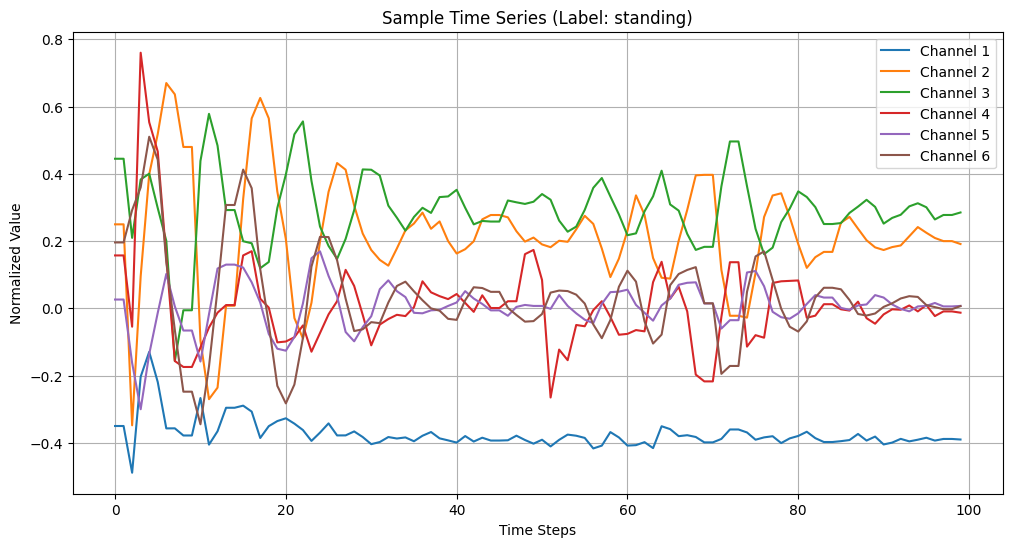

In [23]:
X_train,y_train = load_basic_motions(split="train",return_X_y=True)
X_test,y_test = load_basic_motions(split='test',return_X_y=True)

train_dataset = BasicMotionDataset(X_train,y_train)
test_dataset = BasicMotionDataset(X_test,y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=0)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False,num_workers=0)

plot_sample(train_dataset,idx=0)

In [24]:
model = BasicMotionCNN(num_classes=4,use_batch_norm=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [25]:
# Training loop with metrics tracking
epochs = 50
train_losses = []
test_losses = []
accuracies = []
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs,labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()  
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs,labels)
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    test_loss /= len(test_dataset)
    accuracy = correct/total*100
    test_losses.append(test_loss)  
    accuracies.append(accuracy)  
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

C:\Users\Liwa08\AppData\Local\Temp\ipykernel_16928\395422217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = np.stack([sample[channel].values for channel in range(self.X.shape[1])])


Epoch 1/50, Train Loss: 1.1596, Test Loss: 1.2830, Test Accuracy: 75.00%
Epoch 2/50, Train Loss: 0.3994, Test Loss: 1.1334, Test Accuracy: 57.50%
Epoch 3/50, Train Loss: 0.1954, Test Loss: 0.9717, Test Accuracy: 57.50%
Epoch 4/50, Train Loss: 0.1160, Test Loss: 0.8123, Test Accuracy: 62.50%
Epoch 5/50, Train Loss: 0.0410, Test Loss: 0.6616, Test Accuracy: 70.00%
Epoch 6/50, Train Loss: 0.0195, Test Loss: 0.5434, Test Accuracy: 75.00%
Epoch 7/50, Train Loss: 0.0153, Test Loss: 0.4590, Test Accuracy: 75.00%
Epoch 8/50, Train Loss: 0.0058, Test Loss: 0.3346, Test Accuracy: 80.00%
Epoch 9/50, Train Loss: 0.0033, Test Loss: 0.2260, Test Accuracy: 87.50%
Epoch 10/50, Train Loss: 0.0029, Test Loss: 0.1285, Test Accuracy: 92.50%
Epoch 11/50, Train Loss: 0.0012, Test Loss: 0.0596, Test Accuracy: 100.00%
Epoch 12/50, Train Loss: 0.0060, Test Loss: 0.0251, Test Accuracy: 100.00%
Epoch 13/50, Train Loss: 0.0017, Test Loss: 0.0127, Test Accuracy: 100.00%
Epoch 14/50, Train Loss: 0.0012, Test Loss: 

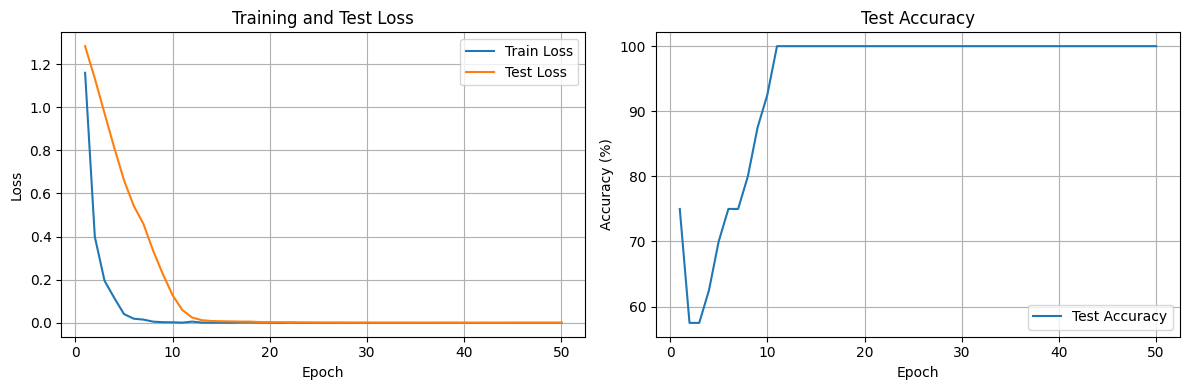

In [26]:
# Plot training and test metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracies, label='Test Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


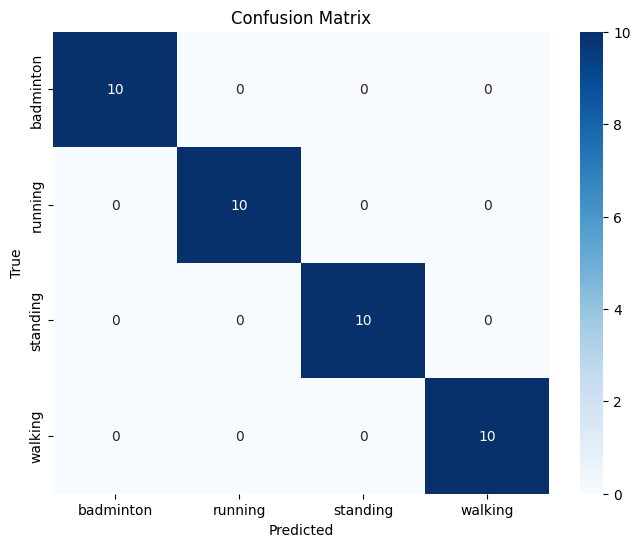

In [27]:
# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = list(train_dataset.label_map.keys())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()